# Data Loading and Basic Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold

# 1. Load all tables
patients = pd.read_csv("patients.csv")
diagnoses = pd.read_csv("diagnoses.csv")
medications = pd.read_csv("medications.csv")
lab_results = pd.read_csv("lab_results.csv")
outcomes = pd.read_csv("outcomes.csv")

# 2. Standardize patient_id format
for df in [patients, diagnoses, medications, lab_results, outcomes]:
    df["patient_id"] = df["patient_id"].astype(str)

# 3. Check duplicates
for name, df in zip(["patients", "diagnoses", "medications", "lab_results", "outcomes"],
                    [patients, diagnoses, medications, lab_results, outcomes]):
    print(f"{name} duplicate rows: {df.duplicated().sum()}")
    df.drop_duplicates(inplace=True)

# 4. Check missing values
print("Missing value ratio per table:")
for name, df in zip(["patients", "diagnoses", "medications", "lab_results", "outcomes"],
                    [patients, diagnoses, medications, lab_results, outcomes]):
    print(f"\n{name}:")
    print(df.isnull().mean().sort_values(ascending=False).head(10))

patients duplicate rows: 0
diagnoses duplicate rows: 0
medications duplicate rows: 0
lab_results duplicate rows: 0
outcomes duplicate rows: 0
Missing value ratio per table:

patients:
patient_id                   0.0
age                          0.0
dx_osteoarthritis            0.0
dx_hypothyroidism            0.0
dx_anxiety                   0.0
dx_depression                0.0
dx_asthma                    0.0
dx_copd                      0.0
dx_chronic_kidney_disease    0.0
dx_atrial_fibrillation       0.0
dtype: float64

diagnoses:
secondary_diagnoses    0.41566
secondary_icd10s       0.41566
patient_id             0.00000
visit_date             0.00000
visit_type             0.00000
primary_diagnosis      0.00000
primary_icd10          0.00000
provider_specialty     0.00000
dtype: float64

medications:
patient_id       0.0
medication       0.0
dose             0.0
unit             0.0
frequency        0.0
indication       0.0
start_date       0.0
duration_days    0.0
is_generic    

In [2]:
# 5. Handle critical missing values
# ----------------------
# diagnoses: 41.5% missing in secondary_diagnoses & secondary_icd10s
# ----------------------
# Fill with empty string (meaning "no secondary diagnoses")
diagnoses["secondary_diagnoses"] = diagnoses["secondary_diagnoses"].fillna("")
diagnoses["secondary_icd10s"] = diagnoses["secondary_icd10s"].fillna("")

# ----------------------
# outcomes: 85% missing in days_to_readmission
# ----------------------
# 85% missing = this column is almost useless → drop it
outcomes = outcomes.drop(columns=["days_to_readmission"])

# ----------------------
# patients & medications & lab_results: NO MISSING VALUES → DO NOTHING
# ----------------------

In [3]:
def convert_binary_to_bool(df):
    """
    Automatically detect the columns in the dataset where the values are only 0 and 1, and convert them to boolean type (True/False).
    """
    for col in df.columns:
        unique_vals = sorted(df[col].dropna().unique())

        if unique_vals == [0, 1]:
            df[col] = df[col].astype("boolean")
            print(f"✅ Has been converted to boolean type: {col}")
    
    print("\n🎉 All the 0/1 columns have been converted to boolean type!")
    return df

In [31]:
def convert_bool_to_binary(df):
    """
    Automatically detect boolean columns (True/False) in the dataset, and convert them back to binary values (1 and 0).
    """
    for col in df.columns:
        if df[col].dtype == "boolean" or df[col].dtype == bool:
            df[col] = df[col].astype(int)
            print(f"✅ Converted boolean column to binary: {col}")
    
    print("\n🎉 All boolean columns have been converted to 0/1 binary!")
    return df

# Feature Engineering for Sub-table

## About <patients.csv>

In [5]:
patients

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes
0,P0000001,66,M,23.5,148,81,64,98.4,former,light,...,0,0,1,0,0,0,0,0,1,0
1,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,0,0,0,0,1,0,0,0,1,0
2,P0000003,82,M,17.8,135,57,90,98.2,never,light,...,0,0,1,0,0,0,0,0,0,0
3,P0000004,73,F,28.1,118,83,102,98.9,former,moderate,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,86,F,30.6,156,81,56,98.7,never,heavy,...,0,0,0,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,P0099996,37,M,24.9,106,101,93,98.9,never,light,...,0,0,0,0,0,0,0,0,0,0
99996,P0099997,37,F,27.8,80,95,63,98.7,never,moderate,...,0,0,0,0,0,0,0,1,0,0
99997,P0099998,50,F,28.5,115,83,53,99.2,never,moderate,...,0,0,0,0,0,0,0,0,0,0
99998,P0099999,85,M,34.6,149,73,65,98.5,never,none,...,0,0,0,1,1,0,0,0,1,0


In [6]:
# Perform the conversion
patients = convert_binary_to_bool(patients)

✅ Has been converted to boolean type: dx_hypertension
✅ Has been converted to boolean type: dx_type2_diabetes
✅ Has been converted to boolean type: dx_hyperlipidemia
✅ Has been converted to boolean type: dx_obesity
✅ Has been converted to boolean type: dx_coronary_artery_disease
✅ Has been converted to boolean type: dx_heart_failure
✅ Has been converted to boolean type: dx_atrial_fibrillation
✅ Has been converted to boolean type: dx_chronic_kidney_disease
✅ Has been converted to boolean type: dx_copd
✅ Has been converted to boolean type: dx_asthma
✅ Has been converted to boolean type: dx_depression
✅ Has been converted to boolean type: dx_anxiety
✅ Has been converted to boolean type: dx_hypothyroidism
✅ Has been converted to boolean type: dx_osteoarthritis
✅ Has been converted to boolean type: dx_type1_diabetes

🎉 All the 0/1 columns have been converted to boolean type!


In [7]:
# 1. One-hot encoding for categorical variables
original_cols = patients.columns.tolist() # List of original column names
cat_cols_pat = patients.select_dtypes(exclude=[np.number]).columns.drop("patient_id") # List of non-numeric column names
for col in cat_cols_pat:
    if patients[col].nunique() > 10: # 10 is empirical value
        print(f"High cardinality column {col}, unique values: {patients[col].nunique()}")
        patients.drop(col, axis=1, inplace=True)
    else:
        patients = pd.get_dummies(patients, columns=[col], prefix=col, drop_first=True)

# 2. Standardize numerical features
scaler = StandardScaler()
num_cols_pat = patients.select_dtypes(include=[np.number]).columns.drop(["patient_id"], errors="ignore") # List of numeric column names
patients[num_cols_pat] = scaler.fit_transform(patients[num_cols_pat])

new_cols = patients.columns.tolist() # List of new column names
added_cols = [col for col in new_cols if col not in original_cols]
patients[added_cols]

,sex_M,smoking_status_former,smoking_status_never,alcohol_use_light,alcohol_use_moderate,alcohol_use_none,exercise_level_moderate,exercise_level_sedentary,exercise_level_vigorous,insurance_type_medicaid,...,dx_heart_failure_True,dx_atrial_fibrillation_True,dx_chronic_kidney_disease_True,dx_copd_True,dx_asthma_True,dx_depression_True,dx_anxiety_True,dx_hypothyroidism_True,dx_osteoarthritis_True,dx_type1_diabetes_True
0,True,True,False,True,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,True,False,True,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,True,False,True,True,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,True,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,True,False,False,...,False,False,False,False,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,True,False,True,True,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
99996,False,False,True,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
99997,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
99998,True,False,True,False,False,True,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False


## About <diagnoses.csv>

In [8]:
diagnoses

,patient_id,visit_date,visit_type,primary_diagnosis,primary_icd10,secondary_diagnoses,secondary_icd10s,provider_specialty
0,P0000001,2018-07-26,telehealth,hyperlipidemia,E78.5,chronic_kidney_disease,N18.3,internal_medicine
1,P0000001,2020-04-09,outpatient,hyperlipidemia,E78.5,chronic_kidney_disease|osteoarthritis,N18.3|M19.90,nephrology
2,P0000001,2023-08-12,emergency,chronic_kidney_disease,N18.3,hyperlipidemia,E78.5,internal_medicine
3,P0000001,2022-11-04,outpatient,osteoarthritis,M19.90,hyperlipidemia|chronic_kidney_disease,E78.5|N18.3,internal_medicine
4,P0000002,2020-07-29,outpatient,osteoarthritis,M19.90,type2_diabetes,E11.9,nephrology
...,...,...,...,...,...,...,...,...
274587,P0099999,2018-04-24,outpatient,copd,J44.1,osteoarthritis,M19.90,nephrology
274588,P0100000,2020-07-01,inpatient,osteoarthritis,M19.90,,,internal_medicine
274589,P0100000,2019-08-30,inpatient,asthma,J45.909,hypertension,I10,internal_medicine
274590,P0100000,2022-08-28,emergency,asthma,J45.909,hypertension|osteoarthritis,I10|M19.90,cardiology


In [9]:
# 1. Split secondary ICD codes and diagnoses into list
diagnoses["secondary_icd_list"] = diagnoses["secondary_icd10s"].str.split("|")
diagnoses["secondary_diag_list"] = diagnoses["secondary_diagnoses"].str.split("|")

# 2. Extract the four core columns
primary_mapping = diagnoses[["primary_icd10", "primary_diagnosis"]].drop_duplicates()
primary_mapping.columns = ["icd10_code", "diagnoses_name"]
diagnoses_exploded = diagnoses.explode(["secondary_icd_list", "secondary_diag_list"])
secondary_mapping = diagnoses_exploded[["secondary_icd_list", "secondary_diag_list"]].rename(
    columns={
        "secondary_icd_list": "icd10_code",
        "secondary_diag_list": "diagnoses_name"
    }
).drop_duplicates()

# 3. Merge the diagnostic mappings and generate a complete comparison table
full_mapping = pd.concat([primary_mapping, secondary_mapping], ignore_index=True)
full_mapping = full_mapping.drop_duplicates().reset_index(drop=True)
full_mapping = full_mapping[
    (full_mapping["icd10_code"].str.strip() != "") &
    (full_mapping["diagnoses_name"].str.strip() != "")
] # Delete blank lines

print("ICD Coding - Diagnosis Name Mapping Table：")
print(full_mapping)
full_mapping.to_csv("icd_code_to_name_mapping.csv", index=False, encoding="utf-8")

ICD Coding - Diagnosis Name Mapping Table：
   icd10_code           diagnoses_name
0       E78.5           hyperlipidemia
1       N18.3   chronic_kidney_disease
2      M19.90           osteoarthritis
3       E11.9           type2_diabetes
4         I10             hypertension
5      I25.10  coronary_artery_disease
6       E66.9                  obesity
7       F32.9               depression
8       J44.1                     copd
9      I48.91      atrial_fibrillation
10      F41.9                  anxiety
11    J45.909                   asthma
12      E03.9           hypothyroidism
13      E10.9           type1_diabetes
14      I50.9            heart_failure


In [10]:
# 1. Aggregate visit features
diag_agg = diagnoses.groupby("patient_id").agg(
    total_visits=("visit_date", "count"),
    telehealth_visits=("visit_type", lambda x: sum(x == "telehealth")),
    emergency_visits=("visit_type", lambda x: sum(x == "emergency")),
    inpatient_visits=("visit_type", lambda x: sum(x == "inpatient")),
    outpatient_visits=("visit_type", lambda x: sum(x == "outpatient"))
).reset_index()

# 2. Collect all ICD codes (primary + secondary)
# 2.1 Extract the primary diagnosis ICD
primary_icds = diagnoses[["patient_id", "primary_icd10"]].rename(columns={"primary_icd10": "icd_code"})

# 2.2 Extract the secondary diagnosis ICD
secondary_icds = diagnoses[["patient_id", "secondary_icd_list"]].explode("secondary_icd_list")
secondary_icds = secondary_icds.rename(columns={"secondary_icd_list": "icd_code"})

# 2.3 Filter out null values
all_icds_long = pd.concat([primary_icds, secondary_icds], ignore_index=True)
all_icds_long = all_icds_long[all_icds_long["icd_code"] != ""].dropna(subset=["icd_code"])

# 3. Get top 15 frequent ICD codes
icd_series = all_icds_long["icd_code"].value_counts()
top_icds = icd_series.index

# 4. Create one-hot encoding for ICDs per patient
# 4.1 Group patients by patient ID and ICD number, and count the occurrence frequency of each ICD for each patient.
patient_icd_counts = all_icds_long.groupby(["patient_id", "icd_code"]).size().unstack(fill_value=0)

# 4.2 Fill in the missing ICD codes with 0.
patient_icd = patient_icd_counts.reindex(columns=top_icds, fill_value=0)

# 4.3 Reset the index and generate a standard DataFrame
icd_df = patient_icd.reset_index()

# 5. Convert to dataframe and merge with diag_agg
diag_agg = diag_agg.merge(icd_df, on="patient_id", how="left").fillna(0)

In [11]:
# Perform the conversion
diag_agg = convert_binary_to_bool(diag_agg)


🎉 All the 0/1 columns have been converted to boolean type!


In [12]:
diag_agg

,patient_id,total_visits,telehealth_visits,emergency_visits,inpatient_visits,outpatient_visits,I10,E66.9,E78.5,N18.3,...,M19.90,F41.9,F32.9,I25.10,J45.909,J44.1,E03.9,I50.9,I48.91,E10.9
0,P0000001,4,1,1,0,2,0,0,4,4,...,2,0,0,0,0,0,0,0,0,0
1,P0000002,6,1,0,0,5,4,3,0,0,...,3,0,0,0,3,0,0,0,0,0
2,P0000003,1,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,P0000004,2,0,0,0,2,1,1,2,0,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,1,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,P0099996,1,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,P0099997,4,0,1,0,3,0,4,0,0,...,0,0,0,0,0,0,3,0,0,0
99997,P0099998,3,0,0,0,3,0,0,3,0,...,0,0,0,0,0,0,0,0,0,0
99998,P0099999,3,0,1,0,2,0,0,0,0,...,3,0,0,0,1,1,0,0,0,0



=== Analysis of ICD Feature Sparsity ===
Proportion of zero values: 83.15%


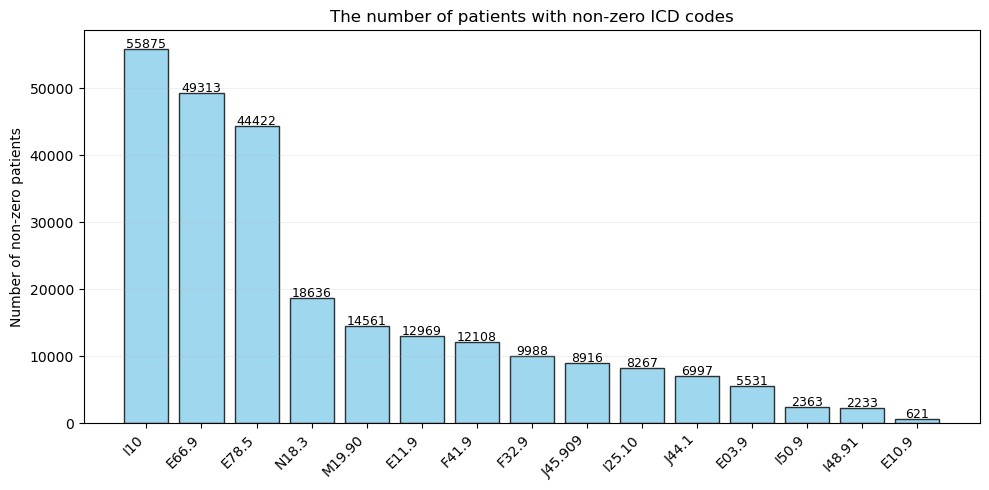

In [13]:
visit_cols = ['total_visits', 'telehealth_visits', 'emergency_visits', 'inpatient_visits', 'outpatient_visits']
icd_cols = [col for col in diag_agg.columns if col not in ['patient_id'] + visit_cols]

# 1. Sporadicity analysis
zero_ratio = (diag_agg[icd_cols] == 0).sum().sum() / (diag_agg[icd_cols].shape[0] * diag_agg[icd_cols].shape[1])
print(f"\n=== Analysis of ICD Feature Sparsity ===")
print(f"Proportion of zero values: {zero_ratio:.2%}")

# 2. Visualization of the distribution of the number of patients with non-zero ICD values
icd_cols = [col for col in diag_agg.columns if col not in ["patient_id"] + visit_cols]
icd_nonzero = diag_agg[icd_cols].astype(bool).sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(icd_nonzero.index, icd_nonzero.values, color="skyblue", edgecolor="black", alpha=0.8)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 150,
             f'{int(height)}', ha='center', fontsize=9)

plt.title("The number of patients with non-zero ICD codes")
plt.ylabel("Number of non-zero patients")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [14]:
# Optimize data types to significantly reduce memory usage
# 1. Number of visits column: Using int32 is sufficient to cover the maximum number.
visit_cols = ["total_visits", "telehealth_visits", "emergency_visits", "inpatient_visits", "outpatient_visits"]
diag_agg[visit_cols] = diag_agg[visit_cols].astype("int32")

# 2. ICD entry: Use int8 (count usually < 10)
icd_cols = [col for col in diag_agg.columns if col not in ["patient_id"] + visit_cols]
diag_agg[icd_cols] = diag_agg[icd_cols].astype("int8")

# Check the optimized memory usage
print(f"Optimized total memory usage: {diag_agg.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

Optimized total memory usage: 8.77 MB


## About <medications.csv>

In [15]:
medications

,patient_id,medication,dose,unit,frequency,indication,start_date,duration_days,is_generic,adherence_pct
0,P0000001,Rosuvastatin,10.0,mg,daily,hyperlipidemia,2020-03-06,30,1,84.5
1,P0000001,Lisinopril,10.0,mg,daily,chronic_kidney_disease,2020-01-22,30,1,81.0
2,P0000001,Erythropoietin,4000.0,units,weekly,chronic_kidney_disease,2021-05-24,90,0,77.1
3,P0000001,Ibuprofen,400.0,mg,three times daily,osteoarthritis,2020-03-16,180,1,90.2
4,P0000002,Metoprolol,25.0,mg,twice daily,hypertension,2018-12-21,365,1,100.0
...,...,...,...,...,...,...,...,...,...,...
364169,P0100000,Lisinopril,10.0,mg,daily,hypertension,2021-05-19,90,1,71.5
364170,P0100000,Amlodipine,5.0,mg,daily,hypertension,2020-05-23,365,1,37.5
364171,P0100000,Albuterol,90.0,mcg,as needed,asthma,2020-08-03,90,0,100.0
364172,P0100000,Ibuprofen,400.0,mg,three times daily,osteoarthritis,2019-11-30,180,1,66.2


In [16]:
# Perform the conversion
medications = convert_binary_to_bool(medications)

✅ Has been converted to boolean type: is_generic

🎉 All the 0/1 columns have been converted to boolean type!


In [17]:
# 1. Core clinical features statistical aggregation
med_stats = medications.groupby("patient_id").agg(
    total_medications=("medication", "count"),
    avg_prescription_duration=("duration_days", "mean"),
    avg_adherence_pct=("adherence_pct", "mean"),
    low_adherence_count=("adherence_pct", lambda x: (x < 80).sum()),
    generic_med_ratio=("is_generic", "mean")
).reset_index()

# 2. One-hot for medication frequency (how often drugs are taken)
freq_dummies = pd.get_dummies(medications[["patient_id", "frequency"]], 
                              prefix="freq", columns=["frequency"])
freq_agg = freq_dummies.groupby("patient_id").max().reset_index()

# 3. One-hot for top 15 indications (why drugs are prescribed → diagnoses table)
top_indications = medications["indication"].value_counts().head(15).index
ind_subset = medications[medications["indication"].isin(top_indications)]
ind_dummies = pd.get_dummies(ind_subset[["patient_id", "indication"]], 
                             prefix="ind", columns=["indication"])
ind_agg = ind_dummies.groupby("patient_id").max().reset_index()

# 4. One-hot for top 15 medication names (which drugs patients use)
top_meds = medications["medication"].value_counts().head(15).index
med_subset = medications[medications["medication"].isin(top_meds)]
med_dummies = pd.get_dummies(med_subset[["patient_id", "medication"]], 
                             prefix="med", columns=["medication"])
med_agg_dummies = med_dummies.groupby("patient_id").max().reset_index()

# 5. Merge all medication features
med_agg = med_stats.merge(freq_agg, on="patient_id", how="left")
med_agg = med_agg.merge(ind_agg, on="patient_id", how="left")
med_agg = med_agg.merge(med_agg_dummies, on="patient_id", how="left")
med_agg = med_agg.fillna(0)

In [18]:
med_agg

,patient_id,total_medications,avg_prescription_duration,avg_adherence_pct,low_adherence_count,generic_med_ratio,freq_as needed,freq_daily,freq_three times daily,freq_twice daily,...,med_Erythropoietin,med_Fluticasone,med_Ibuprofen,med_Levothyroxine,med_Lisinopril,med_Losartan,med_Metoprolol,med_Rosuvastatin,med_Sertraline,med_Simvastatin
0,P0000001,4,82.500000,83.200,1,0.75,False,True,True,False,...,True,False,True,False,True,False,False,True,False,False
1,P0000002,4,158.750000,72.750,2,1.0,True,True,False,True,...,False,False,False,False,False,False,True,False,False,False
2,P0000003,4,97.500000,88.750,1,1.0,True,True,False,False,...,True,False,False,False,True,False,False,False,False,False
3,P0000004,4,151.250000,85.075,2,0.75,False,True,False,False,...,False,False,False,False,True,True,False,False,False,True
4,P0000005,6,135.833333,86.100,1,0.666667,True,True,False,True,...,False,True,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94062,P0099996,1,90.000000,66.000,1,1.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
94063,P0099997,1,30.000000,90.900,0,0.0,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
94064,P0099998,1,180.000000,100.000,0,1.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
94065,P0099999,10,157.000000,75.290,6,0.6,True,True,True,True,...,False,True,True,False,False,True,True,False,False,True


## About <lab_results.csv>

In [19]:
lab_results

,patient_id,test_date,test_name,value,unit,reference_low,reference_high,flag,is_abnormal,delta_from_normal
0,P0000001,2019-03-21,WBC,9.551,K/uL,4.5,11.0,normal,0,1.801
1,P0000001,2019-03-21,total_cholesterol,225.729,mg/dL,100.0,199.0,high,1,76.229
2,P0000001,2019-03-21,HDL,67.620,mg/dL,40.0,100.0,normal,0,-2.380
3,P0000001,2019-03-21,potassium,4.423,mEq/L,3.5,5.0,normal,0,0.173
4,P0000001,2019-03-21,sodium,142.463,mEq/L,136.0,145.0,normal,0,1.963
...,...,...,...,...,...,...,...,...,...,...
2827717,P0100000,2019-08-30,ALT,35.304,U/L,7.0,56.0,normal,0,3.804
2827718,P0100000,2019-08-30,AST,18.658,U/L,10.0,40.0,normal,0,-6.342
2827719,P0100000,2019-08-30,hemoglobin,12.940,g/dL,12.0,17.5,normal,0,-1.810
2827720,P0100000,2019-08-30,glucose_fasting,89.697,mg/dL,70.0,99.0,normal,0,5.197


In [20]:
# Perform the conversion
lab_results = convert_binary_to_bool(lab_results)

✅ Has been converted to boolean type: is_abnormal

🎉 All the 0/1 columns have been converted to boolean type!


In [21]:
# 1. Get latest lab results per patient and test
lab_sorted = lab_results.sort_values(["patient_id", "test_date"], ascending=[True, False])
lab_latest = lab_sorted.drop_duplicates(subset=["patient_id", "test_name"], keep="first")
# Avoiding the interference of historical data, it can better reflect the current health status.

# 2. Select top 20 most frequent tests
top_tests = lab_results["test_name"].value_counts().head(20).index
lab_wide = lab_latest.pivot(index="patient_id", columns="test_name", values="value").reset_index()
lab_wide = lab_wide[["patient_id"] + list(top_tests)].fillna(0)

# 3. Standardize lab values
scaler_lab = StandardScaler()
lab_wide[top_tests] = scaler_lab.fit_transform(lab_wide[top_tests])

# 4. Aggregate lab statistics
lab_stats = lab_results.groupby("patient_id").agg(
    abnormal_test_count=("is_abnormal", "sum"),
    abnormal_test_ratio=("is_abnormal", "mean")
).reset_index()

# 5. Merge stats and wide table
lab_agg = lab_stats.merge(lab_wide, on="patient_id", how="left").fillna(0)

In [22]:
lab_agg

,patient_id,abnormal_test_count,abnormal_test_ratio,WBC,glucose_fasting,creatinine,potassium,sodium,ALT,AST,hemoglobin,LDL,total_cholesterol,triglycerides,HDL,eGFR,HbA1c,BNP,troponin_I,TSH
0,P0000001,24,0.461538,0.302615,0.560570,0.414735,1.492517,-0.459662,-0.529113,-1.121716,0.791038,0.522903,0.916692,0.659525,1.180350,2.154650,-0.434425,-0.356746,-0.314423,-0.267904
1,P0000002,10,0.222222,0.603104,-0.479658,-0.495657,-0.139796,1.772851,1.139001,-0.323665,0.603842,-1.126500,-1.180335,-0.982233,-1.071396,-0.475475,1.485023,-0.356746,-0.314423,-0.267904
2,P0000003,4,0.153846,1.191176,-1.094970,1.067633,2.382507,0.132529,0.345849,-0.197403,-0.113194,-0.554811,0.366791,-0.982233,-1.071396,1.799776,-0.434425,3.198542,3.478088,-0.267904
3,P0000004,11,0.305556,0.645504,0.601054,-0.447650,0.758176,1.306941,0.798922,0.596440,2.007261,0.734559,0.668699,1.675541,1.180097,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904
4,P0000005,7,0.269231,0.582825,-0.142103,-0.470780,1.408707,1.765540,-2.290165,-2.237024,1.886843,0.906304,0.693561,0.077852,0.635228,-0.475475,-0.434425,-0.356746,-0.314423,3.506962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,P0099996,8,0.333333,0.121032,0.182130,-0.496530,0.562617,-1.705854,0.281282,0.425887,-0.016859,1.307456,0.804412,-0.176679,0.518488,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904
99996,P0099997,0,0.0,-0.634798,-0.914775,-0.495657,-0.582796,1.248453,1.303722,0.544733,1.087704,-1.126500,-1.180335,-0.982233,-1.071396,-0.475475,-0.434425,-0.356746,-0.314423,4.630133
99997,P0099998,12,0.333333,0.146841,1.380770,-0.519660,0.391005,1.061690,-0.498419,-0.618675,-2.915653,0.755469,0.930611,1.342773,1.165245,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904
99998,P0099999,8,0.333333,1.460325,1.227391,-0.421027,-0.838219,0.204974,0.414819,1.802937,1.306646,1.368304,0.972198,0.840815,0.611868,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904


## About <outcomes.csv>

In [23]:
outcomes

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,primary_drg,total_charges_usd
0,P0000002,2024-08-06,2024-08-09,3,0,0,0,home_health,0,291,8589.79
1,P0000003,2022-05-06,2022-05-08,2,0,0,0,hospice,1,392,22628.17
2,P0000011,2021-12-30,2022-01-08,9,0,0,0,rehab,0,392,27565.97
3,P0000014,2022-06-30,2022-07-04,4,0,0,0,home,0,194,10332.33
4,P0000040,2020-09-19,2020-09-20,1,0,0,0,rehab,0,470,2389.61
...,...,...,...,...,...,...,...,...,...,...,...
10996,P0099972,2019-10-07,2019-10-25,18,0,0,0,home,0,392,15017.53
10997,P0099984,2023-11-01,2023-11-05,4,0,0,0,home,0,392,34502.78
10998,P0099991,2024-09-12,2024-09-17,5,0,0,0,home_health,0,194,32636.67
10999,P0099992,2018-06-22,2018-06-27,5,0,0,0,home_health,0,292,3082.48


In [24]:
# Perform the conversion
outcomes = convert_binary_to_bool(outcomes)

✅ Has been converted to boolean type: icu_admission
✅ Has been converted to boolean type: in_hospital_death
✅ Has been converted to boolean type: readmitted_30d

🎉 All the 0/1 columns have been converted to boolean type!


In [25]:
# 1. One-hot encode discharge_disposition
outcomes_processed = pd.get_dummies(
    outcomes,
    columns=["discharge_disposition"],
    prefix="discharge",
    drop_first=True
)

# 2. Deduplicate: Keep only 1 row per patient (max value for binary labels)
outcome_agg = outcomes_processed.groupby("patient_id").agg({
    "readmitted_30d": "max",
    "in_hospital_death": "max",
    "icu_admission": "max",
    "length_of_stay_days": "mean",
    "admission_date": "count"
}).reset_index()
outcome_agg.rename(columns={
    "length_of_stay_days": "avg_length_of_stay",
    "admission_date": "total_admissions"
}, inplace=True)

# 3. Ensure binary labels are integer type (0/1)
binary_cols = ["readmitted_30d", "in_hospital_death", "icu_admission"]
outcome_agg[binary_cols] = outcome_agg[binary_cols]

# 4. Fill any missing values (if any) with 0
outcome_agg = outcome_agg.fillna(0)

In [26]:
outcome_agg

,patient_id,readmitted_30d,in_hospital_death,icu_admission,avg_length_of_stay,total_admissions
0,P0000002,False,False,False,3.0,1
1,P0000003,True,False,False,2.0,1
2,P0000011,False,False,False,9.0,1
3,P0000014,False,False,False,4.0,1
4,P0000040,False,False,False,1.0,1
...,...,...,...,...,...,...
10996,P0099972,False,False,False,18.0,1
10997,P0099984,False,False,False,4.0,1
10998,P0099991,False,False,False,5.0,1
10999,P0099992,False,False,False,5.0,1


# Feature Engineering for all data

## Merge tables

In [105]:
# Merge all tables on patient_id
final_df = patients.copy()
final_df = final_df.merge(diag_agg, on="patient_id", how="left")
final_df = final_df.merge(med_agg, on="patient_id", how="left")
final_df = final_df.merge(lab_agg, on="patient_id", how="left")
final_df = final_df.merge(outcome_agg, on="patient_id", how="left")

In [106]:
final_df

,patient_id,age,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,charlson_index,sex_M,smoking_status_former,...,eGFR,HbA1c,BNP,troponin_I,TSH,readmitted_30d,in_hospital_death,icu_admission,avg_length_of_stay,total_admissions
0,P0000001,-0.325835,-0.742757,0.745363,-0.271922,-0.674938,-0.406906,1.155364,True,True,...,2.154650,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN
1,P0000002,0.194638,-0.502187,1.264741,0.128946,-2.273239,1.791968,0.180801,True,False,...,-0.475475,1.485023,-0.356746,-0.314423,-0.267904,False,False,False,3.0,1.0
2,P0000003,0.599449,-1.797561,0.070170,-2.196089,1.512212,-0.806701,2.129928,True,False,...,1.799776,-0.434425,3.198542,3.478088,-0.267904,True,False,False,2.0,1.0
3,P0000004,0.078977,0.108489,-0.812774,-0.111574,2.521666,0.592582,-0.793762,False,True,...,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN
4,P0000005,0.830771,0.571122,1.160866,-0.271922,-1.347907,0.192787,-0.793762,False,False,...,-0.475475,-0.434425,-0.356746,-0.314423,3.506962,<NA>,<NA>,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,P0099996,-2.002913,-0.483682,-1.436028,1.331551,1.764575,0.592582,-0.793762,True,False,...,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN
99996,P0099997,-2.002913,0.052973,-2.786413,0.850509,-0.759059,0.192787,-0.793762,False,False,...,-0.475475,-0.434425,-0.356746,-0.314423,4.630133,<NA>,<NA>,<NA>,NaN,NaN
99997,P0099998,-1.251119,0.182510,-0.968587,-0.111574,-1.600270,1.192275,-0.793762,False,False,...,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN
99998,P0099999,0.772940,1.311335,0.797300,-0.913311,-0.590816,-0.207008,0.180801,True,False,...,-0.475475,-0.434425,-0.356746,-0.314423,-0.267904,<NA>,<NA>,<NA>,NaN,NaN


In [96]:
final_df.to_csv("final_df.csv", index=False, encoding="utf-8")

In [107]:
final_df_original = final_df.copy()

# Create a clean dataset by deleting all rows that contain any null values.
final_df_no_missing = final_df.dropna().copy()

final_df_no_missing.to_csv("final_df_no_missing.csv", index=False, encoding="utf-8")

# Clean CSV for supervised learning

This notebook fills missing values with these rules:
- numeric columns: `0`
- boolean columns: `False`
- string columns that represent boolean values: convert to `bool`, then fill `False`
- other text/categorical columns: fill with `"Unknown"`

In [99]:
import warnings

input_path = "final_df.csv"
output_path = "final_df_cleaned_v1.csv"

df = pd.read_csv(input_path)

true_set = {'true','t','1','yes','y'}
false_set = {'false','f','0','no','n'}

warnings.filterwarnings('ignore')
pd.set_option('future.no_silent_downcasting', True)

for col in df.columns:
    s = df[col]

    # 1) numeric columns -> fill missing with 0
    if pd.api.types.is_numeric_dtype(s):
        df[col] = s.fillna(0)

    # 2) native boolean columns -> fill missing with False
    elif pd.api.types.is_bool_dtype(s):
        df[col] = s.fillna(False).astype(bool)

    # 3) string columns that actually mean True/False -> convert to bool, then fill False
    else:
        non_null = s.dropna().astype(str).str.strip()
        lower = set(non_null.str.lower().unique().tolist())

        if len(lower) > 0 and lower.issubset(true_set | false_set):
            mapped = s.astype(str).str.strip().str.lower().map(
                lambda x: True if x in true_set else (False if x in false_set else np.nan)
            )
            df[col] = mapped.fillna(False).astype(bool)
        else:
            # 4) other text/categorical columns -> fill missing with "Unknown"
            df[col] = s.fillna("Unknown")

print("Shape:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))

df.to_csv(output_path, index=False)
print(f"Saved cleaned file to: {output_path}")

Shape: (100000, 118)
Remaining missing values: 0
Saved cleaned file to: final_df_cleaned_v1.csv


In [100]:
df = pd.read_csv("final_df_cleaned_v1.csv")

# Full Feature Statistical Analysis
print("=" * 80)
print("FEATURE STATISTICAL ANALYSIS - BEFORE CLEANING")
print("=" * 80)

# Define non-feature columns
exclude_cols = ["patient_id", "readmitted_30d", "in_hospital_death", 
                "avg_length_of_stay", "icu_admission"] # Prediction label
numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]
feature_df = df[numeric_features].copy()

# 1. Basic dataset info
print(f"[1] Dataset Shape: {df.shape}")
print(f"[2] Number of Numeric Features: {len(numeric_features)}")

# 2. Feature variance analysis → critical for low-variance filtering
print("\n" + "-" * 50)
print("Feature Variance (Low Variance < 0.01)")
print("-" * 50)
var_series = feature_df.var().sort_values()
low_var_features = var_series[var_series < 0.01]
print(f"Features with Variance < 0.01: {len(low_var_features)}")
print("\nTop 20 Lowest Variance Features:")
print(var_series.head(20))

# 3. Correlation analysis → critical for redundancy filtering
print("\n" + "-" * 50)
print("High Correlation Analysis (|r| > 0.8)")
print("-" * 50)
corr_matrix = feature_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = []
for col in upper_tri.columns:
    correlated = upper_tri[col][upper_tri[col] > 0.8].index.tolist()
    for feat in correlated:
        high_corr_pairs.append((col, feat, upper_tri.loc[col, feat]))

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature1", "Feature2", "Correlation"])
    high_corr_df = high_corr_df.sort_values("Correlation", ascending=False)
    print(f"Highly Correlated Feature Pairs (r>0.8): {len(high_corr_df)}")
    print("\nTop Correlated Pairs:")
    print(high_corr_df.head(25))
else:
    print("No highly correlated features found (r <= 0.8)")

# 4. Feature descriptive statistics
print("\n" + "-" * 50)
print("Feature Descriptive Statistics")
print("-" * 50)
print(feature_df.describe().T.round(3))

print("\n" + "=" * 80)
print("STATISTICAL ANALYSIS COMPLETED")
print("Use these results to adjust variance/correlation thresholds")
print("=" * 80)

FEATURE STATISTICAL ANALYSIS - BEFORE CLEANING
[1] Dataset Shape: (100000, 118)
[2] Number of Numeric Features: 52

--------------------------------------------------
Feature Variance (Low Variance < 0.01)
--------------------------------------------------
Features with Variance < 0.01: 0

Top 20 Lowest Variance Features:
abnormal_test_ratio    0.026847
E10.9                  0.046552
I48.91                 0.093440
total_admissions       0.097909
generic_med_ratio      0.100567
I50.9                  0.137347
E03.9                  0.229830
inpatient_visits       0.277634
J45.909                0.361705
J44.1                  0.401351
F32.9                  0.403555
emergency_visits       0.412753
telehealth_visits      0.416355
I25.10                 0.469817
F41.9                  0.535956
M19.90                 0.581953
E11.9                  0.712199
TSH                    1.000010
BNP                    1.000010
LDL                    1.000010
dtype: float64

--------------------

In [101]:
selected_features = numeric_features.copy()
final_df_cleaned = df[exclude_cols + selected_features].copy()

# ==========================================================
# CORRECT & CONTROLLED HIGH CORRELATION REMOVAL
# Follow medical rules:
# 1. KEEP diagnoses (dx_ / ICD codes)
# 2. DELETE lab measures & redundant features
# ==========================================================

forced_drop = [
    # Blood lipid tests (all removed, retaining "dx_hyperlipidemia")
    'LDL',
    'HDL',
    'total_cholesterol',
    'triglycerides',
    
    # Redundant statistical features (deletion)
    'abnormal_test_ratio'
]

# Keep ALL other features
to_drop = [col for col in forced_drop if col in df.columns]
final_df_cleaned = df.drop(columns=to_drop, errors="ignore")

# Print summary
print("="*60)
print("FEATURE SELECTION COMPLETED")
print(f"Original numeric features: {len(numeric_features)}")
print(f"After correlation removal: {final_df_cleaned.shape[1] - len(exclude_cols)}")
print("Dropped features:", to_drop)
print("="*60)

FEATURE SELECTION COMPLETED
Original numeric features: 52
After correlation removal: 108
Dropped features: ['LDL', 'HDL', 'total_cholesterol', 'triglycerides', 'abnormal_test_ratio']


In [104]:
final_df_cleaned.to_csv("final_df_cleaned_v2.csv", index=False, encoding="utf-8")

# Train Test Split

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

In [109]:
# Count the number of unique values in each column and identify the potential label column
potential_label_cols = []
for col in final_df_cleaned.columns:
    n_unique = final_df_cleaned[col].nunique()
    # Usually, the number of unique values in the label column is very small (such as 2, 3 or a few categories)
    if n_unique <= 5: 
        potential_label_cols.append({
            "Column name": col,
            "The number of unique values": n_unique,
            "Categorical distribution": final_df_cleaned[col].value_counts(normalize=True).round(3).to_dict()
        })

# Arrange the results into a table
df_label_candidates = pd.DataFrame(potential_label_cols)
print("\nPotential label columns and their distribution：")
df_label_candidates.to_csv("label_candidates.csv", index=False, encoding="utf-8")
df_label_candidates


Potential label columns and their distribution：


,Column name,The number of unique values,Categorical distribution
0,sex_M,2,"{False: 0.507, True: 0.493}"
1,smoking_status_former,2,"{False: 0.749, True: 0.251}"
2,smoking_status_never,2,"{True: 0.561, False: 0.439}"
3,alcohol_use_light,2,"{False: 0.629, True: 0.371}"
4,alcohol_use_moderate,2,"{False: 0.77, True: 0.23}"
...,...,...,...
61,med_Simvastatin,2,"{False: 0.73, True: 0.27}"
62,readmitted_30d,2,"{False: 0.984, True: 0.016}"
63,in_hospital_death,2,"{False: 0.999, True: 0.001}"
64,icu_admission,2,"{False: 0.998, True: 0.002}"


# Supervised Learning

## Linear Regression

## Logistic Regression

## Random Forest